In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy import fft
from scipy import signal

%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

Digital filters are delay-based processing units. In short: they affect a signal by overlapping it with delayed versions of the input.
The main application of filters in DSP is the shaping of the spectrum of signals.
This can affect the magnitude spectrum - boost or suppress certain frequencies, 
or the phase spectrum - delay specific frequencies.
Equalizers, reverbs, oscillators and more can be realized with digital filters.

There are two basic categories of digital filters in signal processing: 

- FIR Filters
- IIR Filters 

----

# FIR Filters

Finite Impulse Response (FIR) filters can be considered simple convolution processors. 
They are implemented without recursion, respectively feedback.
And they have a finite impulse response.

FIR filters are robust - allways stable - and easy to design, yet they are more CPU expensive and can cause more delay.


## Impulse Response

The impulse response (IR) of an FIR filter is only the filter coefficients. The following plot shows the IR for a 11th order FIR lowpass filter. All samples after sample 11 are 0 in this $h[n]$:

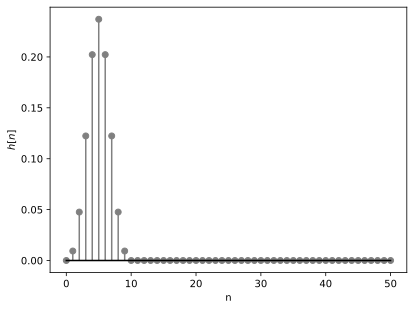

In [12]:

fs = 16000 
fc = 100
N  = 100

numtaps = 11
f       = 0.2

s = signal.firwin(numtaps, f)

s = np.append(s,np.zeros(40))
plt.stem(s, 'gray', markerfmt='gray', basefmt='k')

plt.xlabel('n')
plt.ylabel('$h[n]$');





-----

# IIR Filters

Infinite Impulse Response (IIR) filters are recursive computational structures - they can be unstable.
They have an infinite impulse response, that either converges to zero or - if unstable - to infinity.

IIR filters are used for many time-critical operations, since they are less CPU hungry and create less delay.
In contrast to FIR filters, they can become unstable and alter the phase of signals in sometimes undesirable ways.


## Impulse Response

The following plot shows the IR for a 3rd order Butterworth lowpass filter.
The recursion results in a convergence towards 0.




Text(0, 0.5, '$h[n]$')

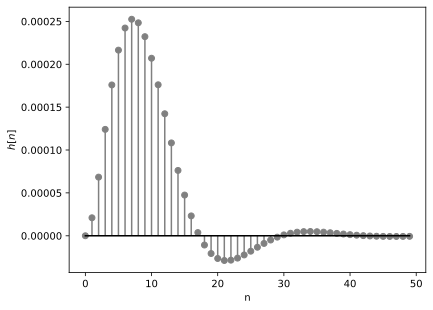

In [11]:



fs = 16000 
fc = 10
N  = 50

t  = np.linspace(0,10,1)

b, a = signal.iirfilter(3, fc/fs, btype='lowpass', analog=True, ftype='butter')

t,h = signal.impulse([b,a],N=N)

plt.stem(h, 'gray', markerfmt='gray', basefmt='k')

plt.xlabel('n')
plt.ylabel('$h[n]$');


